# 0. Supervised Machine Learning Projekt

## Syfte
Syftet med detta projekt är att analysera ett dataset med medicinska mätvärden och använda supervised machine learning för att förutsäga om en tumör är godartad (benign) eller elakartad (malign).

## Frågeställning
Kan vi med hjälp av maskininlärning förutsäga om en tumör är malign eller benign baserat på olika egenskaper hos cellkärnor, såsom storlek, form och textur?

## Metod
Vi använder:
- Exploratory Data Analysis (EDA) för att förstå datans struktur och samband
- Flera ML-modeller (t.ex. Logistic Regression och KNN)
- Dimensionell reduktion (PCA) för att undersöka om färre variabler kan ge liknande resultat
- Modellutvärdering och jämförelse


## 1. Import av bibliotek
Vi importerar nödvändiga bibliotek för dataanalys och maskininlärning.

In [1]:
# Grundläggande bibliotek
import pandas as pd
import numpy as np

# Visualisering
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - data split och preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Sklearn - modeller
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Sklearn - utvärdering
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# (valfritt) PCA
from sklearn.decomposition import PCA

## 2. Dataset

Datasetet innehåller information om brösttumörer och används för att klassificera om en tumör är godartad (benign) eller elakartad (malignant).

Antal observationer: 569  
Antal variabler: 30 (features) + 1 target-variabel  

Samtliga variabler är numeriska och beskriver egenskaper hos cellkärnor, såsom storlek, form och textur.

Datasetet är välstrukturerat och innehåller inga saknade värden, vilket gör det lämpligt för maskininlärning.

Target-variabeln:
- 0 = malignant (elakartad)
- 1 = benign (godartad)

In [2]:
# Ladda dataset från sklearn
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

# Skapa DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Lägg till target-variabel
df['target'] = data.target

# Visa första raderna
print(df.head())

# Visa hela datasetets dimensioner
print(df.shape)

# Definiera features (X) och target (y)
X = df.drop('target', axis=1)
y = df['target']

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

## 3. Dataöversikt

Här undersöker vi datasetets struktur, datatyper och eventuella saknade värden.

### Observationer

- Datasetet innehåller inga saknade värden, vilket innebär att ingen imputering behövs.
- Samtliga variabler är numeriska (float), vilket förenklar analys och modellering.
- Target-variabeln är binär (0 och 1), vilket gör detta till ett klassificeringsproblem.
- Klassfördelningen är något obalanserad, med fler godartade (benign) än elakartade (malignant) tumörer.

### Tolkning

Eftersom datan är komplett och numerisk krävs minimal preprocessing, vilket gör datasetet väl lämpat för maskininlärning.

Den något obalanserade klassfördelningen kan påverka modellens prestanda och bör tas i beaktning vid utvärdering.

In [3]:
# Visa information om datasetet
df.info()

# Statistisk sammanfattning
df.describe()

# Kontrollera saknade värden
missing_values = df.isnull().sum()
print(missing_values)

# Kontrollera datatyper
print(df.dtypes)

# (valfritt) Antal unika värden per kolumn
df.nunique()

# Klassfördelning (mycket viktigt för ML)
print(y.value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

## 4. Dataförberedelse

För att kunna använda maskininlärning förbereder vi datan genom att dela upp den i tränings- och testdata samt skala variablerna.

### Steg

- Eftersom datasetet inte har saknade värden och endast innehåller numeriska variabler krävs ingen ytterligare datarensning eller kodning.
- Datan delas upp i träningsdata (80 %) och testdata (20 %), med bibehållen klassfördelning (stratifiering).
- Skalning utförs med StandardScaler för att säkerställa att alla variabler har samma skala.
- Skalningen tränas enbart på träningsdata och appliceras sedan på testdata för att undvika data leakage.

### Tolkning

Eftersom variablerna har olika skalor är skalning nödvändig, särskilt för modeller som Logistic Regression och KNN, som är känsliga för avstånd och värdeskala. Detta bidrar till mer stabila och tillförlitliga modellresultat.

Stratifieringen säkerställer att både tränings- och testdata har en liknande fördelning av klasser, vilket gör utvärderingen mer rättvis och representativ.

In [4]:
# Dela upp i tränings- och testdata
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Skala data (StandardScaler)
scaler = StandardScaler()

# Fit ONLY på träningsdata
X_train_scaled = scaler.fit_transform(X_train)

# Transformera testdata
X_test_scaled = scaler.transform(X_test)

## 5. Exploratory Data Analysis (EDA)

I denna sektion analyseras relationer mellan variabler för att bättre förstå datan innan modellering.

### Syfte

- Identifiera vilka variabler som påverkar målvariabeln
- Upptäcka eventuella outliers
- Undersöka korrelationer mellan variabler

### Viktiga insikter

- Vilka variabler verkar påverka målvariabeln mest?
- Finns outliers som kan påverka modellen?
- Finns starka korrelationer mellan variabler?

### Centrala variabler

Baserat på korrelationsanalys och visualiseringar verkar följande variabler vara särskilt relevanta för att skilja mellan godartade och elakartade tumörer:

| Variabel (eng)        | Svensk förklaring                     | Vad mäter den? |
|----------------------|--------------------------------------|----------------|
| worst radius         | Största radie                        | Storleken på cellkärnan |
| worst perimeter      | Största omkrets                      | Ytterkanten av cellkärnan |
| mean concave points  | Medel antal konkava punkter          | Antal inbuktningar i formen |
| worst concavity      | Största konkavitet                   | Hur ojämn/indragen formen är |
| mean radius          | Medel radie                          | Genomsnittlig storlek |
| mean texture         | Medel textur                         | Hur ojämn ytan är |

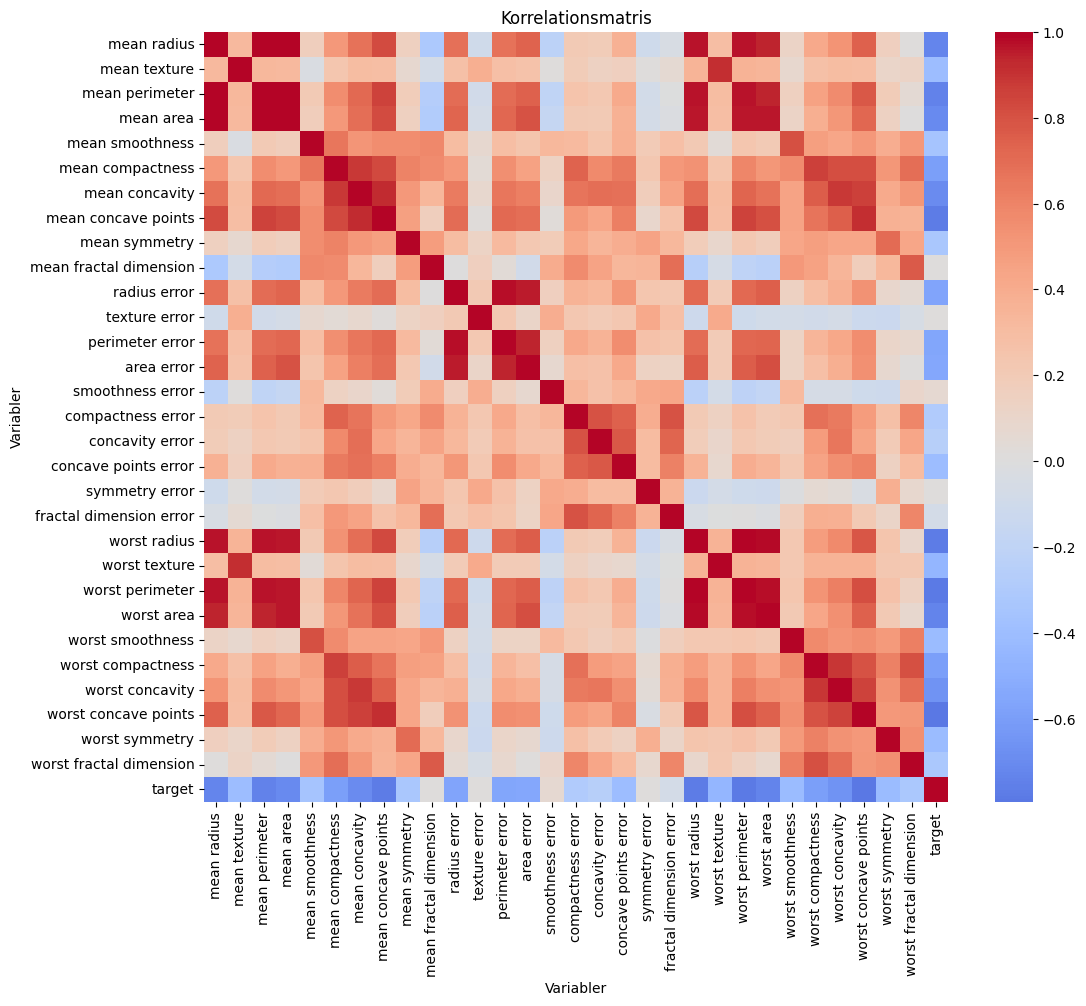

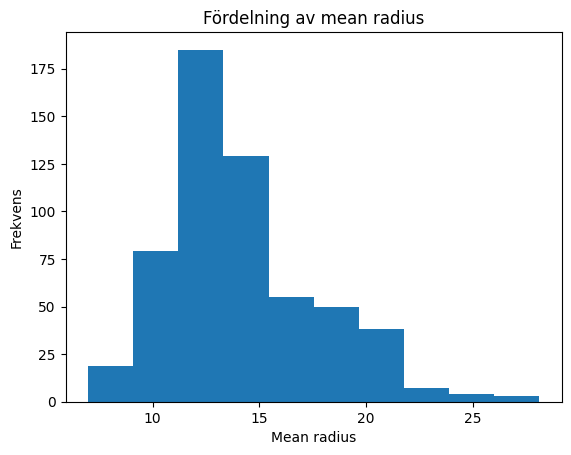

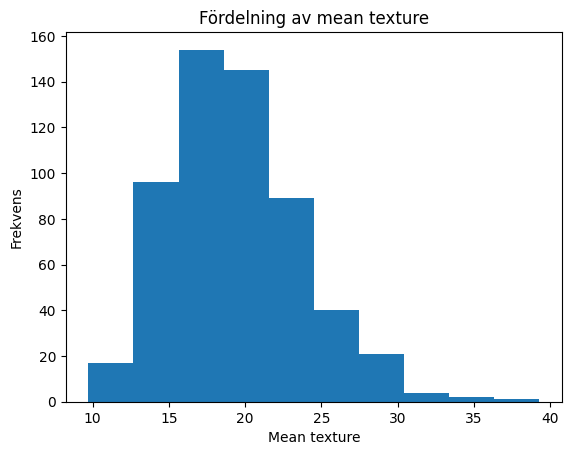

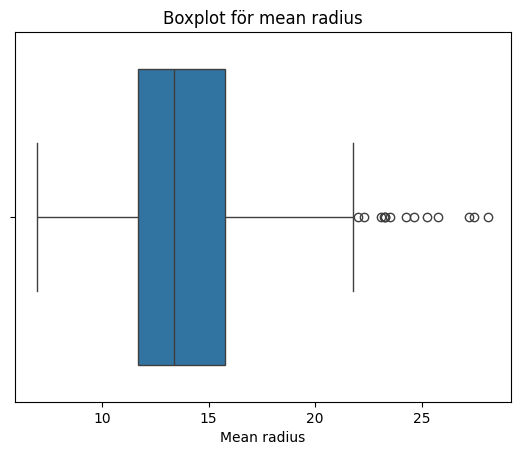

/var/folders/1h/s55shdss4d390jn_qkjnkm_m0000gn/T/ipykernel_87507/270404857.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


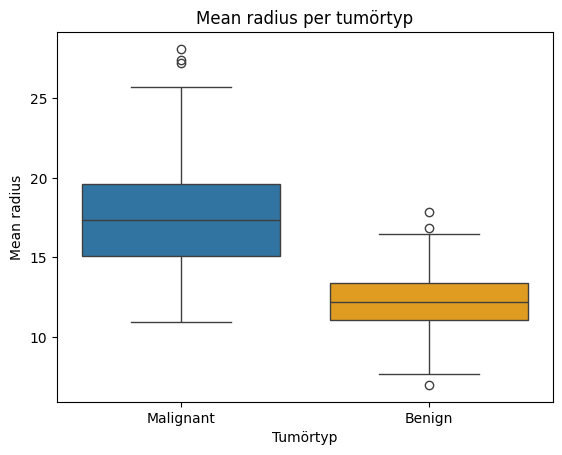

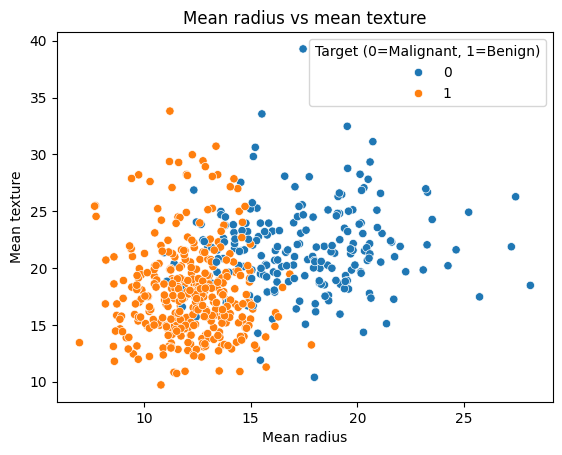

In [6]:
# Korrelationsmatris
corr = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Korrelationsmatris")
plt.xlabel("Variabler")
plt.ylabel("Variabler")
plt.show()


# Fördelning av variabler
plt.hist(df['mean radius'])
plt.title("Fördelning av mean radius")
plt.xlabel("Mean radius")
plt.ylabel("Frekvens")
plt.show()

plt.hist(df['mean texture'])
plt.title("Fördelning av mean texture")
plt.xlabel("Mean texture")
plt.ylabel("Frekvens")
plt.show()


# Boxplot (outliers)
sns.boxplot(x=df['mean radius'])
plt.title("Boxplot för mean radius")
plt.xlabel("Mean radius")
plt.show()


# Relation mellan variabel och target (utan att ändra dataset)
sns.boxplot(
    x=df['target'].map({0: 'Malignant', 1: 'Benign'}),
    y=df['mean radius'],
    palette={
        'Malignant': 'tab:blue',
        'Benign': 'orange'
    }
)
plt.title("Mean radius per tumörtyp")
plt.xlabel("Tumörtyp")
plt.ylabel("Mean radius")
plt.show()


# Scatterplot
sns.scatterplot(
    x=df['mean radius'], 
    y=df['mean texture'], 
    hue=df['target']
)
plt.title("Mean radius vs mean texture")
plt.xlabel("Mean radius")
plt.ylabel("Mean texture")
plt.legend(title="Target (0=Malignant, 1=Benign)")
plt.show()

### Tolkning

Histogrammen visar att variabler som *mean radius* och *mean texture* uppvisar viss skevhet i fördelningen, vilket innebär att datan inte är perfekt normalfördelad. Detta kan påverka vissa modeller och motiverar användning av skalning.

Boxploten för *mean radius* visar förekomst av outliers, särskilt vid högre värden. Dessa extremvärden kan påverka modellens stabilitet, framför allt för avståndsbaserade metoder som KNN.

Analysen av relationen mellan *mean radius* och målvariabeln visar en tydlig separation mellan klasserna. Tumörer med större radie tenderar att vara elakartade (target = 0), medan mindre värden oftare är godartade (target = 1). Detta tyder på att variabeln är informativ för klassificering.

Scatterploten visar att kombinationen av *mean radius* och *mean texture* ger en viss separation mellan klasserna, även om det finns överlappning. Detta indikerar att klassificeringen inte är trivial och att flera variabler behöver kombineras för att uppnå god prestanda.

Korrelationsanalysen visar att flera variabler är starkt korrelerade, vilket tyder på multikollinearitet och redundans i datan. Detta motiverar användning av dimensionell reduktion (PCA) i senare steg.

Sammantaget visar EDA att datasetet innehåller tydliga mönster och delvis separerbara klasser, vilket är gynnsamt för maskininlärning. Samtidigt finns viss komplexitet och överlappning mellan klasserna.

Baserat på dessa insikter kommer vi att använda både Logistic Regression och KNN samt undersöka effekten av PCA för att hantera korrelerade variabler och förbättra modellens prestanda.

## 6. Basmodell

Vi börjar med en enkel modell (Logistic Regression) för att skapa en baseline och få en första uppfattning om hur väl datan kan klassificeras.

### Resultat

- Accuracy: **0.982 (98.2%)**

### Tolkning

- Basmodellen uppnår en mycket hög accuracy, vilket tyder på att datasetet innehåller tydliga mönster som gör det möjligt att skilja mellan godartade och elakartade tumörer.
- Detta indikerar att variablerna är informativa och att klasserna i stor utsträckning är separerbara.
- Eftersom datasetet är något obalanserat är det dock viktigt att komplettera med fler utvärderingsmått, såsom precision, recall och ROC-AUC, vilket analyseras i nästa steg.

Accuracy (basmodell): 0.9824561403508771


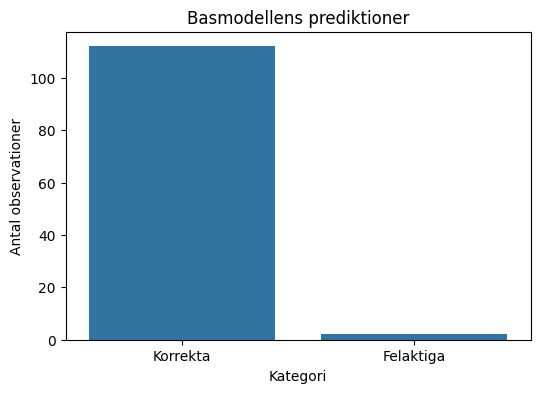

In [7]:
# Skapa första modell (t.ex. LogisticRegression eller KNN)
model = LogisticRegression(max_iter=1000)

# Träna modellen
model.fit(X_train_scaled, y_train)

# Gör prediktioner
y_pred = model.predict(X_test_scaled)

# Beräkna accuracy
accuracy_bas = accuracy_score(y_test, y_pred)

# Skriv ut resultat
print("Accuracy (basmodell):", accuracy_bas)

# Räkna antal korrekta och felaktiga prediktioner
correct = (y_pred == y_test).sum()
incorrect = (y_pred != y_test).sum()

# Skapa DataFrame
results_df = pd.DataFrame({
    'Kategori': ['Korrekta', 'Felaktiga'],
    'Antal': [correct, incorrect]
})

# Barplot
plt.figure(figsize=(6,4))
sns.barplot(data=results_df, x='Kategori', y='Antal')

plt.title("Basmodellens prediktioner")
plt.ylabel("Antal observationer")
plt.show()

## 7. Modellutvärdering (Basmodell)

Vi utvärderar modellen med flera metoder:

- Confusion matrix: visar rätt/fel klassificeringar
- Precision & Recall
- ROC-AUC: modellens förmåga att skilja klasser

### Tolkning

- Hur många observationer klassificeras korrekt/fel?
- Hur ser precision och recall ut?
- Är modellen bättre på att identifiera benign eller malign?
- Varför är recall särskilt viktigt i ett medicinskt sammanhang?

In [ ]:
# Confusion matrix
# → Beräkna confusion matrix baserat på y_test och y_pred
# → Visualisera den som en heatmap (t.ex. med seaborn)

# Classification report
# → Skriv ut precision, recall och f1-score
# → Fundera särskilt på recall för klassen "malignant"

# ROC-AUC
# → Använd predict_proba för att få sannolikheter
# → Beräkna ROC-AUC score
# → (valfritt) Plotta ROC-kurva (fpr vs tpr)

## 8. Dimensionell reduktion (PCA)

Vi använder PCA (Principal Component Analysis) för att reducera antalet variabler och undersöka om modellen kan uppnå liknande eller bättre prestanda med färre dimensioner.

### Uppgift

- Bestäm antal komponenter (t.ex. 2 eller baserat på förklarad varians)
- Applicera PCA på träningsdata
- Transformera både tränings- och testdata
- Träna modellen igen på PCA-transformerad data
- Gör prediktioner och beräkna accuracy
- PCA appliceras på den skalade datan (X_train_scaled och X_test_scaled)
- Kontrollera hur stor andel av variansen som förklaras

### Resultat (att fylla i)

- Accuracy efter PCA: [...]
- Förklarad varians (explained variance ratio): [...]

### Tolkning (att fylla i)

- Hur påverkar PCA modellens prestanda jämfört med basmodellen?
- Hur många komponenter krävs för att förklara majoriteten av variansen?
- Vad säger detta om redundans och korrelation i datan?

In [ ]:
# Bestäm antal komponenter (t.ex. 2 eller baserat på förklarad varians)

# Skapa PCA-objekt
# pca = PCA(n_components=...)

# Fit PCA på träningsdata
# X_train_pca = pca.fit_transform(X_train_scaled)

# Transformera testdata
# X_test_pca = pca.transform(X_test_scaled)

# Kontrollera förklarad varians
# print(pca.explained_variance_ratio_)

# Träna modell igen på PCA-data
# model_pca.fit(X_train_pca, y_train)

# Gör prediktioner
# y_pred_pca = model_pca.predict(X_test_pca)

# Beräkna accuracy för PCA-modellen
# accuracy_pca = accuracy_score(y_test, y_pred_pca)

## 9. Modellförbättring (andra modeller)

Vi försöker förbättra modellen genom:
- Justering av hyperparametrar
- Test av andra algoritmer

### Resultat
- Hur påverkar valet av k modellens prestanda?
- Vilket k-värde fungerar bäst?
- Varför skiljer sig resultaten mellan modellerna?

In [ ]:
# Skapa en KNN-modell
model2 = KNeighborsClassifier(n_neighbors=5)

# Träna modellen (använd SKALAD data)
model2.fit(X_train_scaled, y_train)

# Gör prediktioner
y_pred_model2 = model2.predict(X_test_scaled)

# Beräkna accuracy
accuracy_model2 = accuracy_score(y_test, y_pred_model2)

print("Accuracy (KNN, k=5):", accuracy_model2)


# Testa olika k-värden
for k in [3, 5, 7, 9]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"k={k}, accuracy={accuracy_score(y_test, y_pred)}")


# (valfritt) Testa Logistic Regression igen för jämförelse
model3 = LogisticRegression(max_iter=1000)
model3.fit(X_train_scaled, y_train)
y_pred_model3 = model3.predict(X_test_scaled)
accuracy_model3 = accuracy_score(y_test, y_pred_model3)

print("Accuracy (Logistic Regression):", accuracy_model3)

Accuracy (KNN, k=5): 0.956140350877193
k=3, accuracy=0.9824561403508771
k=5, accuracy=0.956140350877193
k=7, accuracy=0.9736842105263158
k=9, accuracy=0.9736842105263158
Accuracy (Logistic Regression): 0.9824561403508771


## 10. Jämförelse av modeller

Här jämför vi samtliga modeller baserat på deras prestanda.

| Modell                     | Accuracy | ROC-AUC |
|----------------------------|---------|--------|
| Basmodell (Logistic Regression) | 0.982   | ... |
| Modell 2 (KNN)             | ...     | ... |
| PCA-modell                 | ...     | ... |

---
För att jämförelsen ska vara rättvis används samma testdata för alla modeller.

Samtliga modeller jämförs med samma mått (accuracy och eventuellt ROC-AUC).

### Analys

Den modell som presterar bäst är [modell], vilket kan bero på att:

- [förklaring, t.ex. bättre hantering av variabler]
- [PCA minskade brus / förbättrade struktur]
- [hyperparametrar optimerades]

### Utvärdering av förbättrade modeller

De förbättrade modellerna visar [högre/lägre] prestanda jämfört med basmodellen.

Detta tyder på att:
- [PCA / hyperparametrar] har påverkat modellen genom att [...]

In [ ]:
# Skapa en lista eller dictionary med resultat från alla modeller

# Exempel:
# results = {
#     "Basmodell": accuracy_bas,
#     "Modell 2": accuracy_model2,
#     "PCA-modell": accuracy_pca
# }

# Skapa en DataFrame för jämförelse
# import pandas as pd
# df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])

# (valfritt) Lägg till ROC-AUC om ni har det
# df_results['ROC-AUC'] = [...]

# Visa tabellen
# print(df_results)

# (valfritt) Visualisera jämförelsen med barplot
# df_results.plot(kind='bar')

## 11. Slutsats

### Sammanfattning
- Vi har undersökt om det går att förutsäga **[målvariabel]** baserat på **[viktigaste features/variabler]**.
- Resultaten visar att det är **[möjligt / delvis möjligt / svårt]** att göra denna prediktion med maskininlärning.

### Modellprestanda
- Vi testade följande modeller:
  - [Modell 1, t.ex. Logistic Regression]
  - [Modell 2, t.ex. KNN]

- Bästa modell:
  - **[Modellnamn]** presterade bäst med:
    - Accuracy: **[värde]**
    - (ev. F1-score: **[värde]**)

- Kort tolkning:
  - Modellen fungerade bra eftersom **[t.ex. tydliga mönster i datan / separerbara klasser]**
  - / eller: Prestandan var begränsad på grund av **[brus / obalanserad data / få observationer]**

### Effekt av PCA / UMAP
- Vi använde **[PCA / UMAP / ingen]** för att reducera dimensioner.
- Resultat:
  - Med dimensionell reduktion: **[bättre / sämre / ungefär samma]**
- Tolkning:
  - **[t.ex. datan innehåller redundanta variabler / viktig information gick förlorad]**

### Begränsningar
- Datasetet:
  - **[litet / obalanserat / saknar vissa variabler]**
- Modell:
  - **[ingen hyperparameter-tuning / enkel modell]**
- Övrigt:
  - **[t.ex. risk för överanpassning / generaliserbarhet oklar]**

### Förbättringar
- Testa fler modeller:
  - **[t.ex. Random Forest, SVM]**
- Förbättra preprocessing:
  - **[feature engineering / bättre hantering av missing values]**
- Optimera modeller:
  - **[hyperparameter tuning]**
- Data:
  - **[större eller mer varierat dataset]**

---

## 12. Reflektion

### Insikter
- Ett viktigt resultat var att:
  - **[t.ex. enkla modeller fungerade bättre än förväntat]**

### Vad var oväntat?
- **[t.ex. PCA förbättrade inte modellen / vissa variabler var viktigare än väntat]**

### Vad skulle vi göra annorlunda?
- **[t.ex. börja med tydligare feature selection]**
- **[lägga mer tid på modelljämförelse]**
- **[testa fler metoder tidigare]**